In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings("ignore")
 

In [3]:
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
COLORS = {"left": "#4C72B0", "right": "#DD8452"}

In [11]:
df = pd.read_csv(r"D:\py\5243\project3\ga4_data.csv")

# Convert timestamp (Google Analytics uses microseconds)
df["event_time"] = pd.to_datetime(df["event_timestamp"], unit="us")

print("=== Basic Data Information ===")
print(f"Total rows: {len(df)}")
print(f"Number of columns: {df.shape[1]}")

print("\nEvent count by variant:")
print(df["variant"].value_counts())

print("\nEvent distribution:")
print(df["event_name"].value_counts())

=== Basic Data Information ===
Total rows: 2938
Number of columns: 26

Event count by variant:
variant
right    1690
left     1248
Name: count, dtype: int64

Event distribution:
event_name
ui_click                    365
task_complete               334
section_view                322
section_time_spent          322
ui_click_right              216
task_complete_right         202
section_view_right          181
section_time_spent_right    181
ui_click_left               149
section_view_left           141
section_time_spent_left     141
task_complete_left          132
app_loaded                   95
app_loaded_right             51
app_loaded_left              44
task_error                   31
task_error_left              17
task_error_right             14
Name: count, dtype: int64


In [12]:
session_keys = ["user_pseudo_id", "ga_session_id", "variant"]

def build_session(g):
    return pd.Series({
        "n_section_views":   (g["event_name"] == "section_view").sum(),
        "n_clicks":          (g["event_name"] == "ui_click").sum(),
        "n_task_complete":   (g["event_name"] == "task_complete").sum(),
        "n_task_error":      (g["event_name"] == "task_error").sum(),
        "total_seconds":     pd.to_numeric(
                                 g.loc[g["event_name"] == "section_time_spent", "seconds_spent"],
                                 errors="coerce").fillna(0).sum(),
        "used_sample":       int((g["control_id"] == "load_sample_btn").sum() > 0),
        "completed_any":     int((g["event_name"] == "task_complete").sum() > 0),
        "bounce":            int(
                                 ((g["event_name"] == "section_view").sum() <= 1) and
                                 ((g["event_name"] == "ui_click").sum() == 0)
                             ),
    })

session_df = (df.groupby(session_keys)
                .apply(build_session)
                .reset_index())

# CTR = clicks / section views (avoid division by zero)
session_df["ctr"] = (
    session_df["n_clicks"] /
    session_df["n_section_views"].replace(0, np.nan)
)

print("\n=== Session-Level Data Preview ===")
print(session_df.head())



=== Session-Level Data Preview ===
     user_pseudo_id  ga_session_id variant  n_section_views  n_clicks   
0  032d42e97fc7646d     1776122849    left              2.0       0.0  \
1  08f5fa9f56d4fb2f     1775964295   right              3.0       0.0   
2  095dfd830b96fb66     1776000830    left              1.0       0.0   
3  0b7243bcaeca73c0     1776288907   right              2.0       2.0   
4  0f8987abd2f43cf9     1775860214    left              1.0       0.0   

   n_task_complete  n_task_error  total_seconds  used_sample  completed_any   
0              0.0           0.0           31.0          0.0            0.0  \
1              0.0           0.0           36.0          0.0            0.0   
2              0.0           0.0           16.0          0.0            0.0   
3              2.0           0.0           48.0          1.0            1.0   
4              0.0           0.0           12.0          0.0            0.0   

   bounce  ctr  
0     0.0  0.0  
1     0.0  0.0  

In [13]:
summary = session_df.groupby("variant").agg(
    n_sessions        = ("ga_session_id", "count"),
    avg_clicks        = ("n_clicks",       "mean"),
    avg_section_views = ("n_section_views","mean"),
    avg_ctr           = ("ctr",            "mean"),
    avg_seconds       = ("total_seconds",  "mean"),
    completion_rate   = ("completed_any",  "mean"),
    bounce_rate       = ("bounce",         "mean"),
    error_rate        = ("n_task_error",   "mean"),
).round(3)

print("\n=== Summary Table ===")
print(summary.to_string())


=== Summary Table ===
         n_sessions  avg_clicks  avg_section_views  avg_ctr  avg_seconds  completion_rate  bounce_rate  error_rate
variant                                                                                                           
left             44       3.386              3.205    0.697       99.341            0.568        0.227       0.386
right            51       4.235              3.549    0.864      112.157            0.647        0.098       0.275


In [15]:
left  = session_df[session_df["variant"] == "left"]
right = session_df[session_df["variant"] == "right"]

def ttest_report(name, a, b):
    t, p = stats.ttest_ind(a.dropna(), b.dropna(), equal_var=False)
    diff = a.mean() - b.mean()
    print(f"\n[t-test] {name}")
    print(f"  Left mean={a.mean():.3f}, Right mean={b.mean():.3f}, Diff={diff:+.3f}")
    print(f"  t={t:.3f}, p={p:.4f} {'*Significant (p<0.05)' if p < 0.05 else 'Not significant'}")

def ztest_report(name, col):
    counts = session_df.groupby("variant")[col].sum().reindex(["left","right"]).astype(int)
    ns     = session_df.groupby("variant")[col].count().reindex(["left","right"]).astype(int)

    z, p = proportions_ztest(count=counts.values,nobs=ns.values)
    pl, pr = counts["left"]/ns["left"], counts["right"]/ns["right"]

    print(f"\n[z-test] {name}")
    print(f"  Left={pl:.3f}, Right={pr:.3f}, Diff={pl-pr:+.3f}")
    print(f"  z={z:.3f}, p={p:.4f} {'*Significant (p<0.05)' if p < 0.05 else 'Not significant'}")

print("\n" + "="*50)
print("Statistical Test Results")
print("="*50)

ttest_report("Clicks per session",  left["n_clicks"],     right["n_clicks"])
ttest_report("Total seconds spent", left["total_seconds"],right["total_seconds"])
ttest_report("CTR",                 left["ctr"],           right["ctr"])

ztest_report("Task completion rate","completed_any")
ztest_report("Bounce rate",         "bounce")

# Mann-Whitney test (robust check for skewed distributions)
u, p_mw = stats.mannwhitneyu(
    left["total_seconds"],
    right["total_seconds"],
    alternative="two-sided"
)
print(f"\n[Mann-Whitney] Total seconds: U={u:.1f}, p={p_mw:.4f}")



Statistical Test Results

[t-test] Clicks per session
  Left mean=3.386, Right mean=4.235, Diff=-0.849
  t=-0.952, p=0.3433 Not significant

[t-test] Total seconds spent
  Left mean=99.341, Right mean=112.157, Diff=-12.816
  t=-0.632, p=0.5287 Not significant

[t-test] CTR
  Left mean=0.697, Right mean=0.864, Diff=-0.167
  t=-1.144, p=0.2556 Not significant

[z-test] Task completion rate
  Left=0.568, Right=0.647, Diff=-0.079
  z=-0.786, p=0.4318 Not significant

[z-test] Bounce rate
  Left=0.227, Right=0.098, Diff=+0.129
  z=1.722, p=0.0850 Not significant

[Mann-Whitney] Total seconds: U=1012.0, p=0.4137


In [16]:
time_df = df[df["event_name"] == "section_time_spent"].copy()
time_df["seconds_spent"] = pd.to_numeric(time_df["seconds_spent"], errors="coerce")

section_time = (time_df.groupby(["variant","section_name"])["seconds_spent"]
                        .mean()
                        .reset_index())

print("\n=== Average Time per Section (seconds) ===")
print(section_time.pivot(index="section_name", columns="variant", values="seconds_spent").round(2))


=== Average Time per Section (seconds) ===
variant               left  right
section_name                     
Cleaning             43.92  39.36
Data Upload          32.05  33.12
EDA                  33.38  40.03
Export               13.21  11.05
Feature Engineering  38.05  37.44
User Guide           13.78  16.14


In [17]:

clicks_by_sec = (df[df["event_name"] == "ui_click"]
                   .groupby(["variant","section_name"])
                   .size().reset_index(name="clicks"))

views_by_sec  = (df[df["event_name"] == "section_view"]
                   .groupby(["variant","section_name"])
                   .size().reset_index(name="views"))

sec_ctr = clicks_by_sec.merge(
    views_by_sec,
    on=["variant","section_name"],
    how="outer"
).fillna(0)

sec_ctr["ctr"] = sec_ctr["clicks"] / sec_ctr["views"].replace(0, np.nan)

print("\n=== Section-Level CTR ===")
print(sec_ctr.pivot(index="section_name", columns="variant", values="ctr").round(3))


=== Section-Level CTR ===
variant               left  right
section_name                     
Cleaning             2.480  2.758
Data Upload          0.605  0.647
EDA                  0.762  0.793
Export               0.857  0.950
Feature Engineering  1.650  1.852
User Guide           0.000  0.000


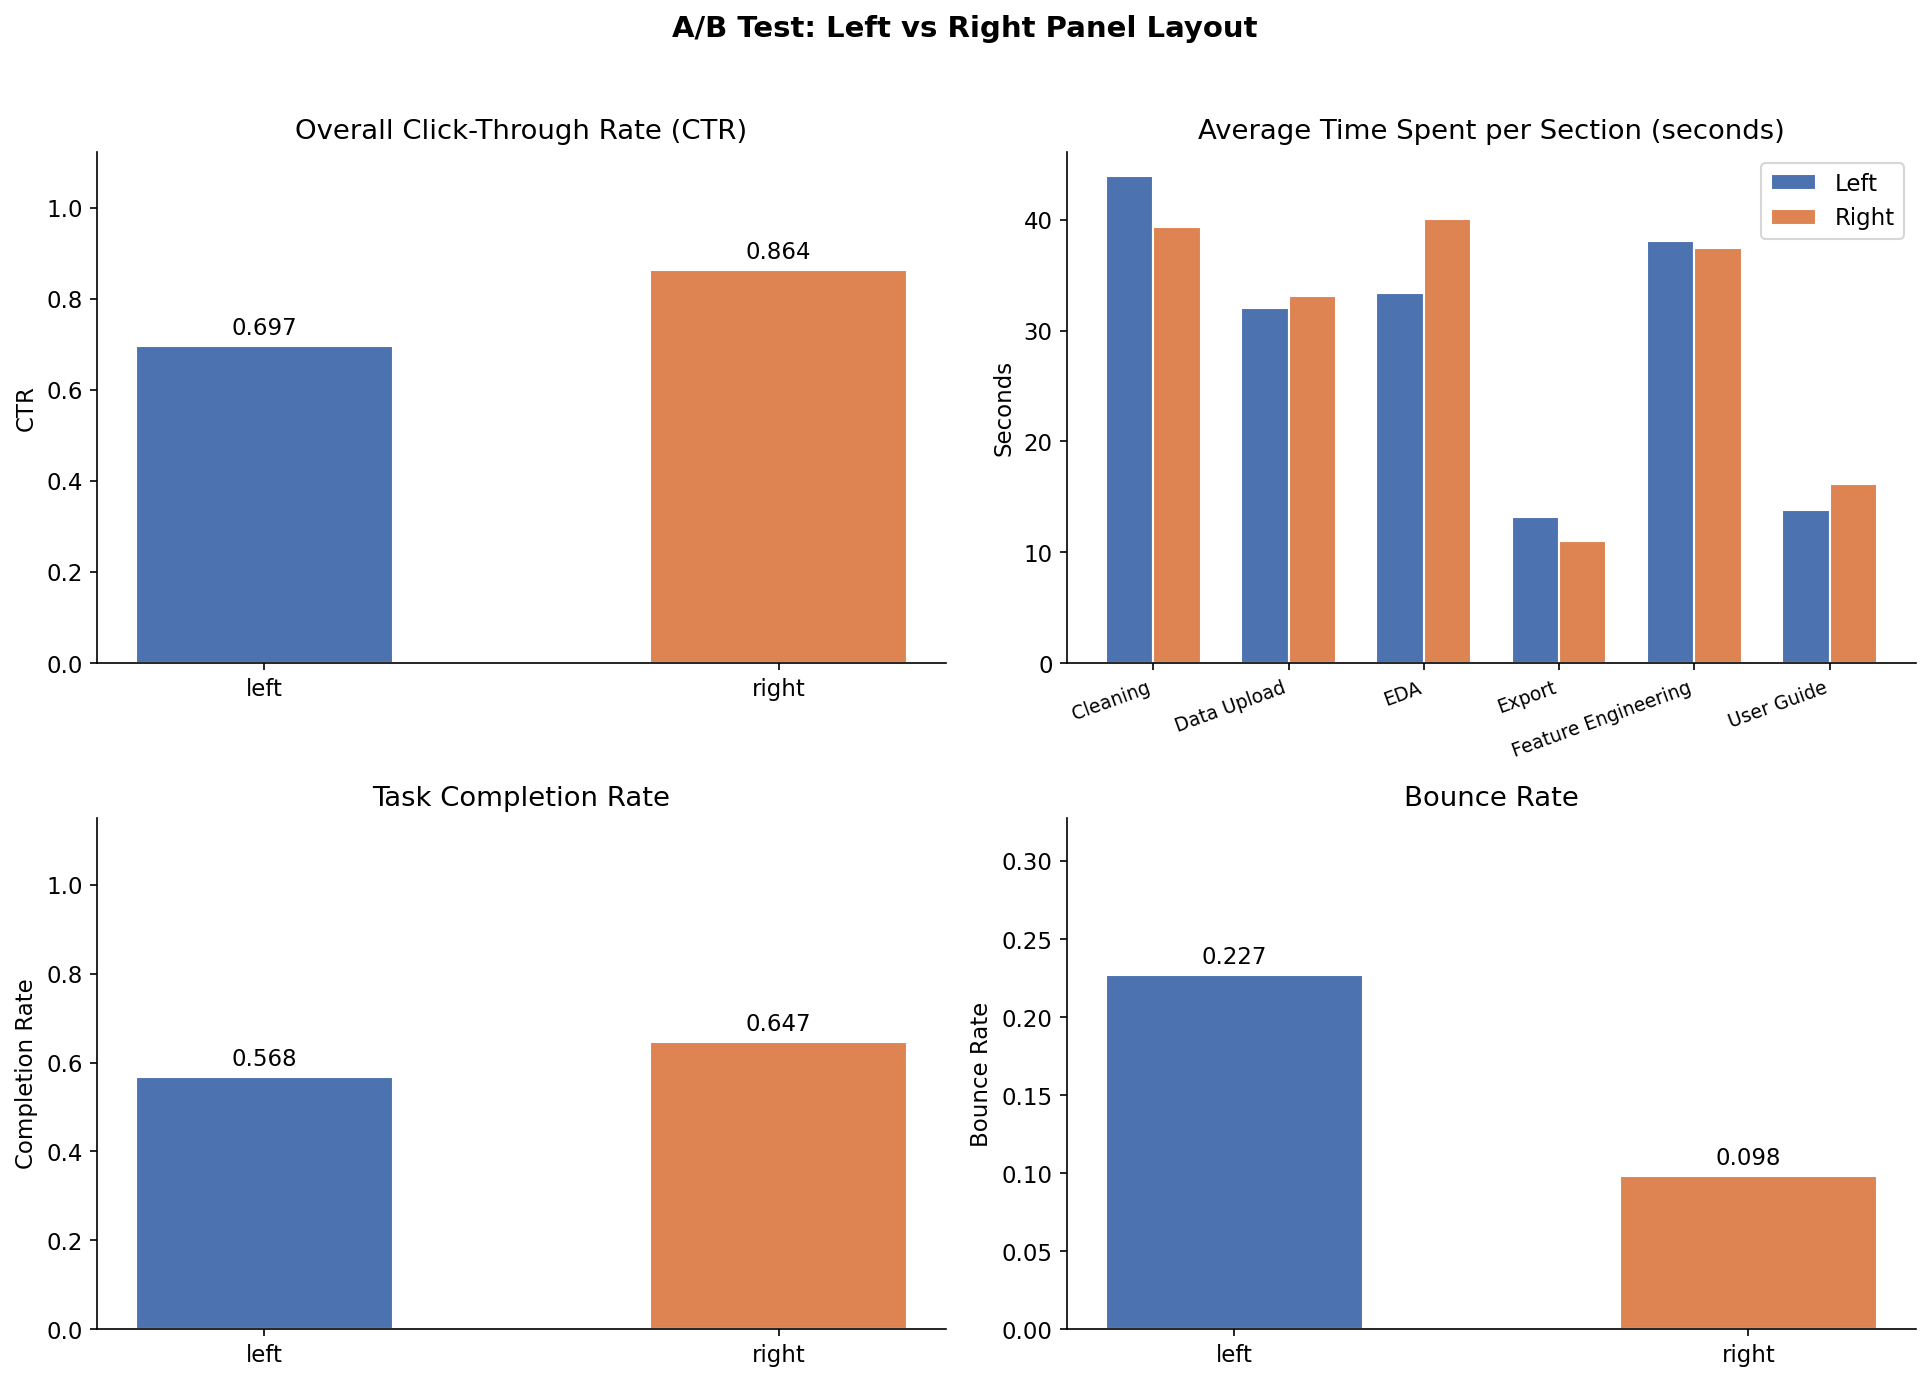

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("A/B Test: Left vs Right Panel Layout", fontsize=14, fontweight="bold", y=1.02)

variants = ["left", "right"]
bar_colors = [COLORS["left"], COLORS["right"]]

# --- Plot 1: Overall CTR ---
ax = axes[0, 0]
ctr_vals = summary["avg_ctr"].reindex(["left","right"])

bars = ax.bar(variants, ctr_vals, color=bar_colors, width=0.5, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3)

ax.set_title("Overall Click-Through Rate (CTR)")
ax.set_ylabel("CTR")
ax.set_ylim(0, ctr_vals.max() * 1.3)

ax = axes[0, 1]

pivot_time = section_time.pivot(
    index="section_name",
    columns="variant",
    values="seconds_spent"
).fillna(0)

x = np.arange(len(pivot_time))
w = 0.35

b1 = ax.bar(x - w/2, pivot_time.get("left", 0), w,
            label="Left", color=COLORS["left"], edgecolor="white")

b2 = ax.bar(x + w/2, pivot_time.get("right", 0), w,
            label="Right", color=COLORS["right"], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(pivot_time.index, rotation=20, ha="right", fontsize=9)

ax.set_title("Average Time Spent per Section (seconds)")
ax.set_ylabel("Seconds")
ax.legend()

ax = axes[1, 0]

comp_vals = summary["completion_rate"].reindex(["left","right"])

bars = ax.bar(variants, comp_vals, color=bar_colors, width=0.5, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3)

ax.set_title("Task Completion Rate")
ax.set_ylabel("Completion Rate")
ax.set_ylim(0, 1.15)

ax = axes[1, 1]

bounce_vals = summary["bounce_rate"].reindex(["left","right"])

bars = ax.bar(variants, bounce_vals, color=bar_colors, width=0.5, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3)

ax.set_title("Bounce Rate")
ax.set_ylabel("Bounce Rate")
ax.set_ylim(0, bounce_vals.max() * 1.4 + 0.01)

plt.tight_layout()

#plt.savefig(r"D:\py\5243\project3\ab_test_figures.png", bbox_inches="tight")
plt.show()